In [42]:
import os
import yaml
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Polygon as mPolygon
from PIL import Image

In [43]:
# Paths
dataset_path = r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/"
yaml_file = os.path.join(dataset_path, 'data.yaml') # "/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/data.yaml"
images_dir = os.path.join(dataset_path, 'train', 'aug_images') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/images"
yolo_labels_dir = os.path.join(dataset_path, 'train', 'aug_labels') # r"/home/c/choton/beemachine/datasets/Beemachine_Partwhole_v4/train/labels"
images = os.listdir(images_dir)

In [44]:
# Load class names from YAML
with open(yaml_file, "r") as f:
    data = yaml.safe_load(f)
class_names = data["names"]
print("class names:", class_names)

# Function to plot yolo annotation
def plot_yolo_annotation(image_path, label_path, ax):
    image = Image.open(image_path)
    w, h = image.size

    # Read YOLO segmentation annotations
    annotations = []
    with open(label_path, "r") as f:
        for line in f.readlines():
            parts = line.strip().split()
            cls_id = int(parts[0])
            coords = list(map(float, parts[1:]))
            # Convert normalized coords → pixel coords
            poly = [(coords[i] * w, coords[i+1] * h) for i in range(0, len(coords), 2)]
            annotations.append((cls_id, poly))

    # Plot
    ax.imshow(image)
    ax.set_title("Original partwhole annotations")
    np.random.seed(30)
    class_colors = {cls_id: np.random.rand(3,) for cls_id, _ in annotations}
    for cls_id, poly in annotations:
        polygon = mPolygon(poly, closed=True, edgecolor=class_colors[cls_id], fill=False, linewidth=2)
        ax.add_patch(polygon)
        # Label
        x, y = poly[0]
        label = f"{cls_id, class_names[cls_id]}"
        ax.text(x, y, label, 
                color=class_colors[cls_id], fontsize=10, bbox=dict(facecolor='white', alpha=0.5))

class names: ['abdomen', 'head', 'thorax']


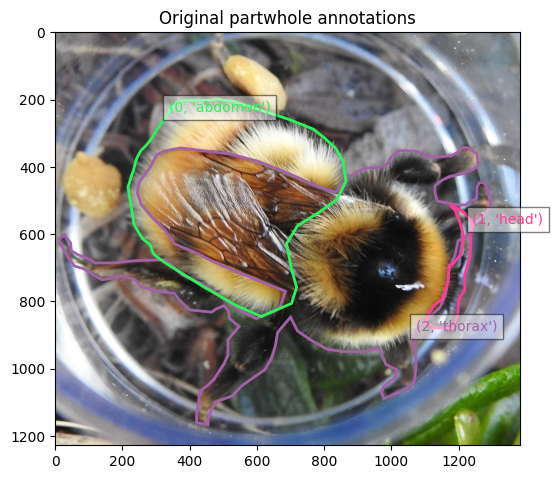

In [45]:
# Get an image and its label
image_file = images[4472]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

fig, axes = plt.subplots(1, 1, figsize=(6,6))
plot_yolo_annotation(image_path, label_path, axes)

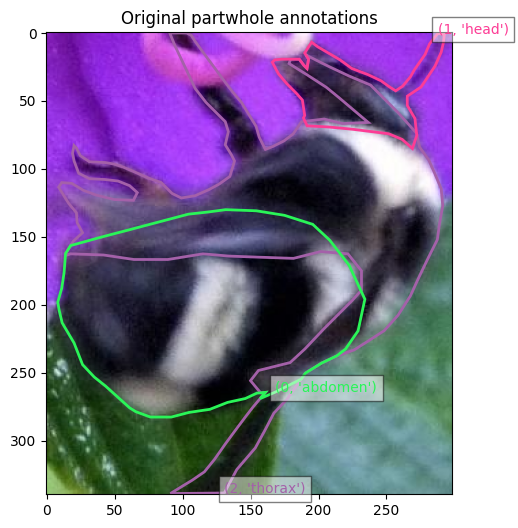

In [46]:
image_file = images[447]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

fig, axes = plt.subplots(1, 1, figsize=(6,6))
plot_yolo_annotation(image_path, label_path, axes)

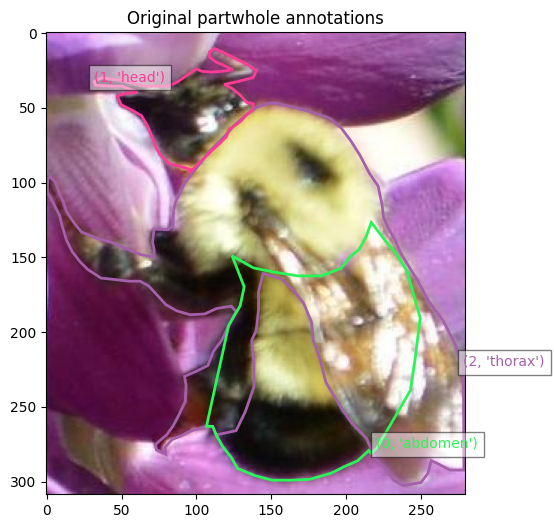

In [47]:
image_file = images[72]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

fig, axes = plt.subplots(1, 1, figsize=(6,6))
plot_yolo_annotation(image_path, label_path, axes)

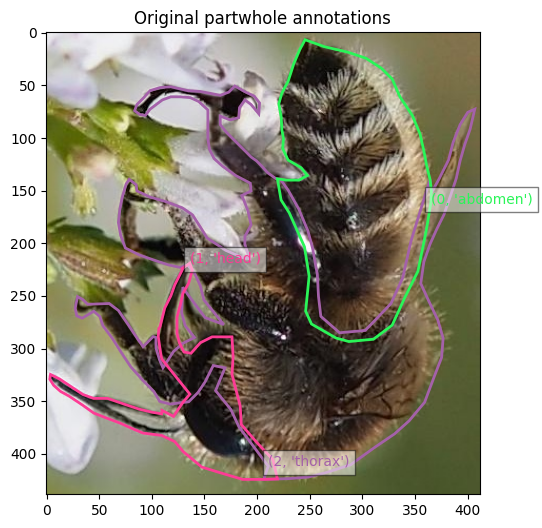

In [48]:
image_file = images[2022]
label_file = os.path.splitext(image_file)[0] + ".txt"

# Get the image and label paths
image_path = os.path.join(images_dir, image_file)
label_path = os.path.join(yolo_labels_dir, label_file)

fig, axes = plt.subplots(1, 1, figsize=(6,6))
plot_yolo_annotation(image_path, label_path, axes)

In [49]:
images.sort() # Sorting images based on the name

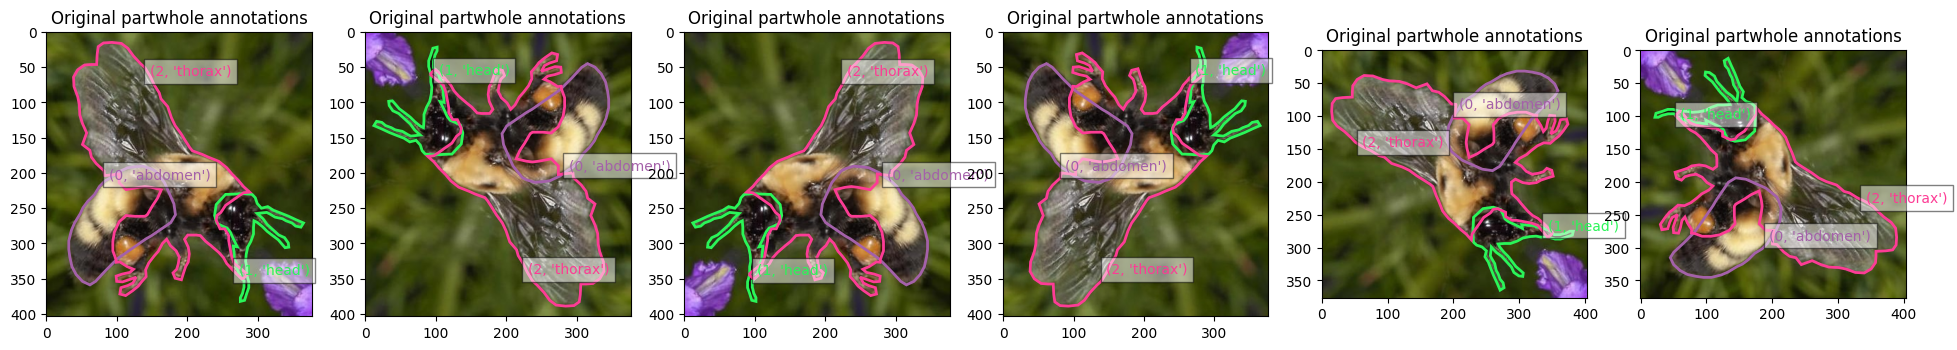

In [50]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    image_file = images[204+i]
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    plot_yolo_annotation(image_path, label_path, axes[i])

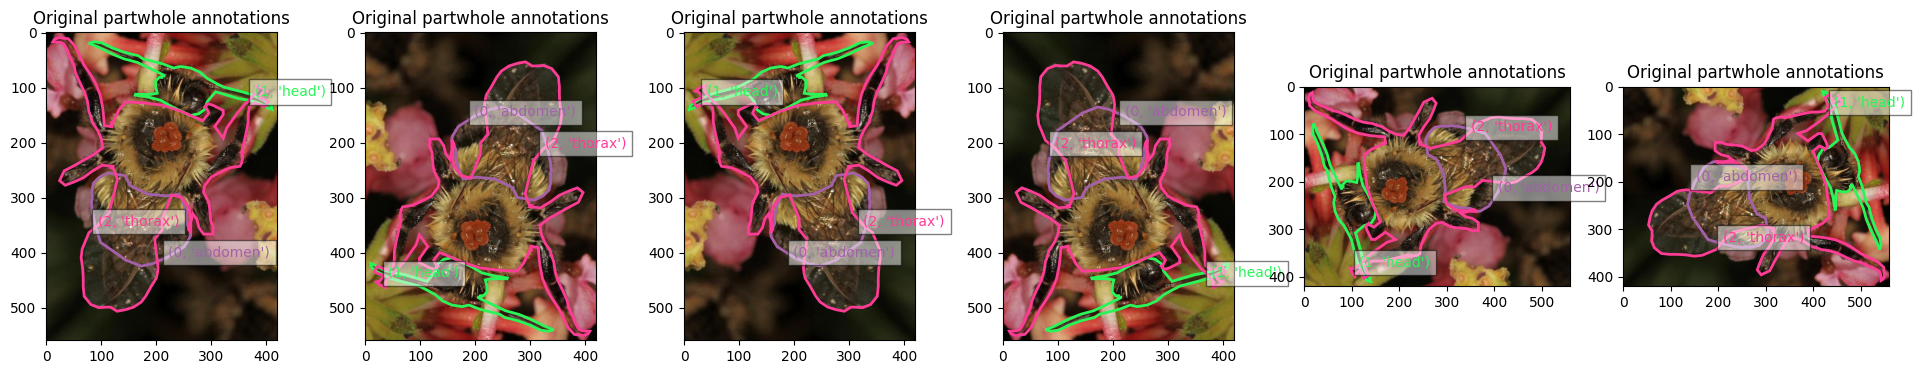

In [51]:
fig, axes = plt.subplots(1, 6, figsize=(24,4))
for i in range(6):
    image_file = images[i]
    label_file = os.path.splitext(image_file)[0] + ".txt"
    image_path = os.path.join(images_dir, image_file)
    label_path = os.path.join(yolo_labels_dir, label_file)
    plot_yolo_annotation(image_path, label_path, axes[i])